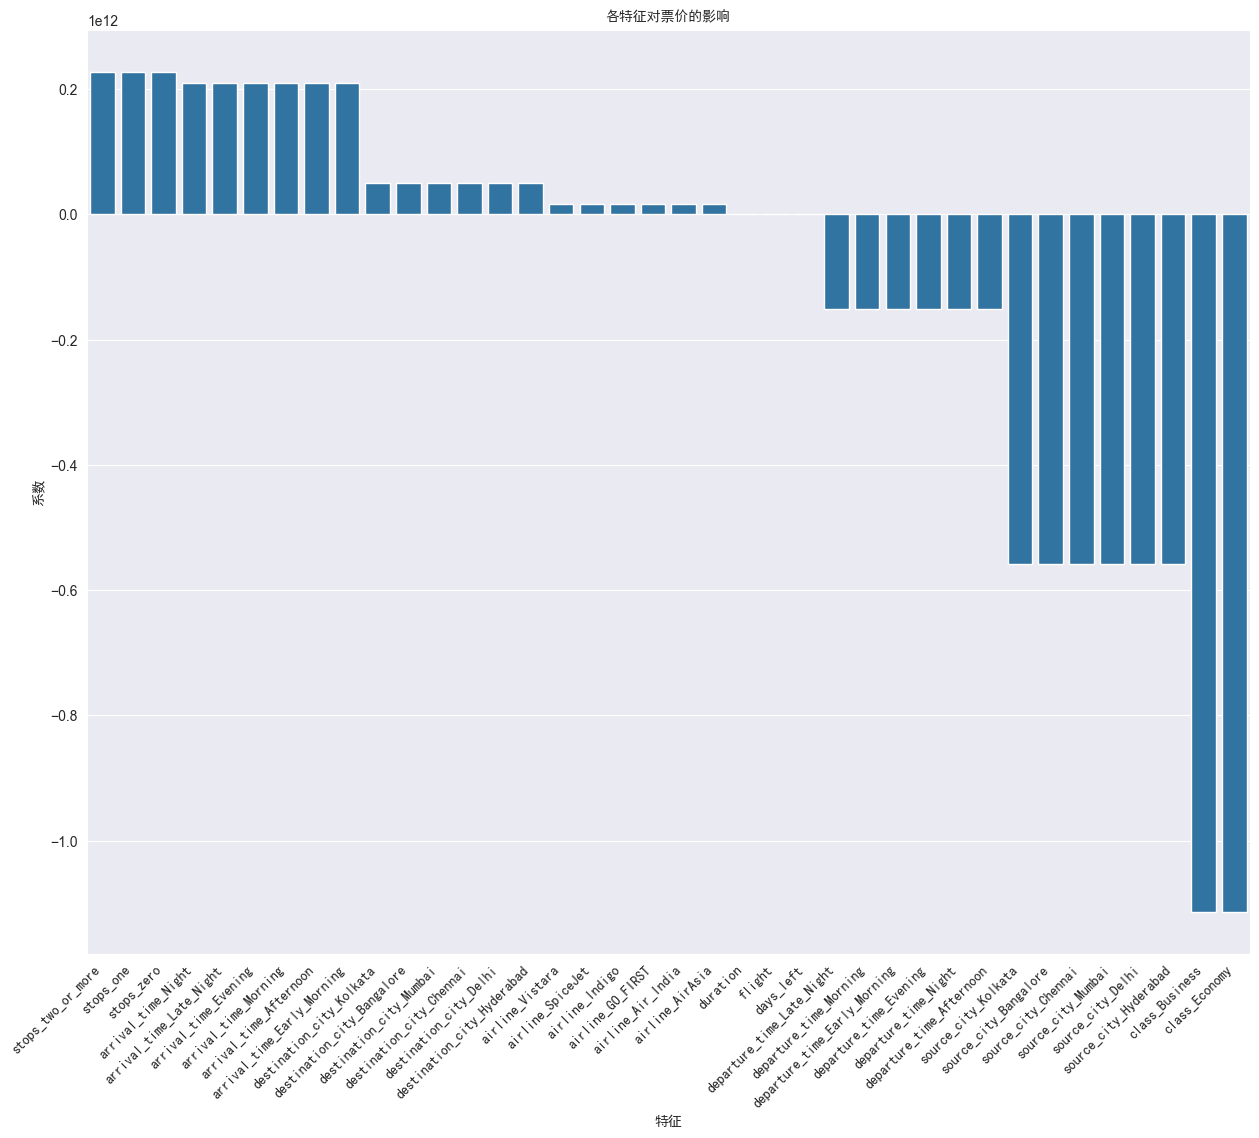

模型系数分析：
                               Coefficient
stops_two_or_more             2.281410e+11
stops_one                     2.281410e+11
stops_zero                    2.281410e+11
arrival_time_Night            2.103474e+11
arrival_time_Late_Night       2.103474e+11
arrival_time_Evening          2.103474e+11
arrival_time_Morning          2.103474e+11
arrival_time_Afternoon        2.103474e+11
arrival_time_Early_Morning    2.103474e+11
destination_city_Kolkata      5.034049e+10
destination_city_Bangalore    5.034049e+10
destination_city_Mumbai       5.034049e+10
destination_city_Chennai      5.034049e+10
destination_city_Delhi        5.034049e+10
destination_city_Hyderabad    5.034049e+10
airline_Vistara               1.734483e+10
airline_SpiceJet              1.734483e+10
airline_Indigo                1.734483e+10
airline_GO_FIRST              1.734483e+10
airline_Air_India             1.734483e+10
airline_AirAsia               1.734483e+10
duration                      1.315994e-02
fli

['flight_price_model.pkl']

In [6]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.font_manager as fm

# Define the file path
file_path = '../data/processed/clean_processed_data.csv'

# Check if the file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {file_path} does not exist.")

# Load data and trained model
df = pd.read_csv(file_path)
model = LinearRegression()

# Assume the training process is completed and load the model
X = df.drop(columns=['price'])
y = df['price']
model.fit(X, y)

# Get model coefficients
coefficients = model.coef_
features = X.columns

# Visualize model coefficients
coef_df = pd.DataFrame(coefficients, index=features, columns=['Coefficient'])
coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)

# Set font properties for Chinese characters
font_path = 'C:/Windows/Fonts/simhei.ttf'  # Path to a font that supports Chinese characters
font_prop = fm.FontProperties(fname=font_path)

plt.figure(figsize=(15, 12))
sns.barplot(x=coef_df.index, y=coef_df['Coefficient'])
plt.title("各特征对票价的影响", fontproperties=font_prop)
plt.xticks(rotation=45, ha='right', fontproperties=font_prop)  # Rotate and align x-axis labels
plt.xlabel("特征", fontproperties=font_prop)
plt.ylabel("系数", fontproperties=font_prop)

# Create figure directory if it doesn't exist
os.makedirs('figure', exist_ok=True)

# Save the plot as an image file in the figure directory
plt.savefig('figure/comparison_plot.png')

# Show the plot
plt.show()

# Summary of results
print("模型系数分析：")
print(coef_df)


# 保存模型
# Save the trained model
joblib.dump(model, 'flight_price_model.pkl')